 # Object detection using resnet18 (spatial preservation version)

 This version final version of the baseline model includes two main improvements:

- Model architecture: the backbone is modified to preserve spatial information. Previously, the ResNet18 backbone was used with its final fully connected layer replaced by an identity which activated the global average pooling, collapsing all spatial information into a single vector. Now, the backbone is extracted manually up to layer4, i.e., the characteristic maps are preserved. A new spatial reduction module is added on top, which applies a 512 to 128 mapping convolution, followed by batch normalization, ReLU activation and an adaptive average pooling to 4×4. This produces a 2048-dimensional vector that retains spatial localization cues. The heads are adjusted accordingly to take 2048 input features instead of 512.
- Loss function: the localization loss is changed from generalized IoU (GIoU) to a composite of complete IoU (CIoU) plus 2.0 times SmoothL1Loss. CIoU penalizes not only the lack of overlap but also the distance between box centers and the difference in aspect ratio, while the SmoothL1 component directly penalizes coordinate distance. This change was motivated by the observation that while v2 improved classification, it still struggled to learn localization effectively.

 ## 1. Imports

In [1]:
%uv pip install ultralytics scikit-learn seaborn opencv-python kagglehub torchmetrics[detection]


Using Python 3.12.6 environment at: /usr/local
Resolved 63 packages in 403ms
⠙ Preparing packages... (0/8)
⠙ Preparing packages... (0/8)
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
kagglehub  ------------------------------ 30.84 KiB/68.98 KiB
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
kagglehub  ------------------------------ 30.84 KiB/68.98 KiB
⠙ Preparing packages... (0/8)
lightning-utilities ------------------------------ 14.80 KiB/31.16 KiB
kagglehub  ------------------------------ 30.84 KiB/68.98 KiB
kagglesdk  ------------------------------     0 B/212.68 KiB
⠙ Preparin

In [2]:
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import shutil
import time
import yaml

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
from torchvision import tv_tensors
from torchvision.transforms import ToTensor
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.ops import complete_box_iou_loss
from PIL import Image
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
from tqdm.notebook import tqdm


 ## 2. download and explore the dataset

In [3]:
# download the dataset
path = kagglehub.dataset_download("orvile/x-ray-baggage-anomaly-detection")
print("Path to dataset files:", path)

# set train, validation and test paths
train_path = os.path.join(path, "train")
val_path = os.path.join(path, "valid")
test_path = os.path.join(path, "test")

# print number of images and labels in the train path
num_train_images = len(os.listdir(os.path.join(train_path, "images")))
num_train_labels = len(os.listdir(os.path.join(train_path, "labels")))
print(f"Number of training images: {num_train_images}")
print(f"Number of training labels: {num_train_labels}")


100%|████████████████████████████████████████████████████████████████████████| 133M/133M [00:01<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/x-ray-baggage-anomaly-detection/versions/1
Number of training images: 6181
Number of training labels: 6181


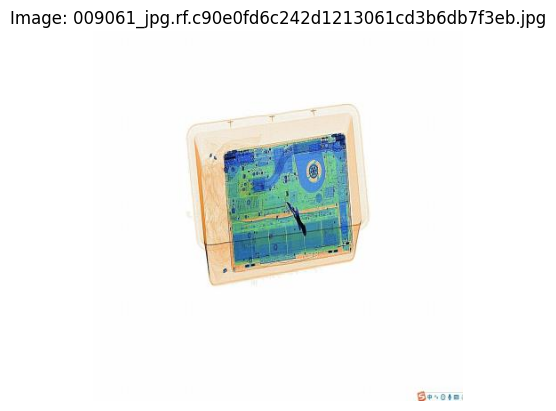

Contents of label file 009061_jpg.rf.c90e0fd6c242d1213061cd3b6db7f3eb.txt:
2 0.5576923076923077 0.515625 0.08052884615384616 0.13221153846153846


In [4]:
# select an image and its corresponding label file to inspect
image_file = os.listdir(os.path.join(train_path, "images"))[20]
label_file = image_file.replace(".jpg", ".txt")

# read the image
image = cv2.imread(os.path.join(train_path, "images", image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# read the label file
with open(os.path.join(train_path, "labels", label_file), "r") as f:
    label_contents = f.read()

# plot the image
plt.imshow(image)
plt.title(f"Image: {image_file}")
plt.axis("off")
plt.show()

print(f"Contents of label file {label_file}:\n{label_contents}")


In [5]:
def draw_yolo_bbox(image_path, label_data):
    # read image, convert to rgb and get dimensions
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape

    for line in label_data.splitlines():
        # take the label data and convert to float
        _, x, y, w, h = map(float, line.split())
        print(f"Label data - x: {x}, y: {y}, w: {w}, h: {h}")

        # compute the bounding box coordinates
        center_x, center_y = int(x * W), int(y * H)
        width, height = int(w * W), int(h * H)

        xmin = int(center_x - (width / 2))
        ymin = int(center_y - (height / 2))
        xmax = int(center_x + (width / 2))
        ymax = int(center_y + (height / 2))

        # draw the bounding box on the image
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Prohibited Objects")
    plt.axis('off')
    plt.show()


Label data - x: 0.5576923076923077, y: 0.515625, w: 0.08052884615384616, h: 0.13221153846153846


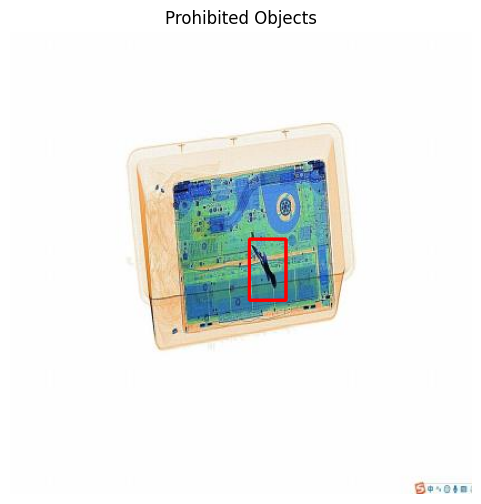

In [6]:
draw_yolo_bbox(os.path.join(train_path, "images", image_file), label_contents)


 ## 3. Image preprocessing

In [7]:
def preprocess_xray(img):
    # clahe (contrast limited adaptive histogram equalization)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    img_clahe = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # sharpening the image
    gaussian_blur = cv2.GaussianBlur(img_clahe, (9, 9), 10.0)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, gaussian_blur, -0.5, 0)

    return img_sharp


In [8]:
def apply_preprocessing_to_folder(src_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    for img_name in os.listdir(src_path):
        img = cv2.imread(os.path.join(src_path, img_name))
        if img is not None:
            processed = preprocess_xray(img)
            cv2.imwrite(os.path.join(dest_path, img_name), processed)

# save processed images in local colab storage
train_images_proc = "/content/dataset_processed/train/images"
val_images_proc = "/content/dataset_processed/valid/images"
test_images_proc = "/content/dataset_processed/test/images"

print("Preprocessing images...")
start_time = time.time()
apply_preprocessing_to_folder(os.path.join(train_path, "images"), train_images_proc)
apply_preprocessing_to_folder(os.path.join(val_path, "images"), val_images_proc)
apply_preprocessing_to_folder(os.path.join(test_path, "images"), test_images_proc)
end_time = time.time()
print(f"Preprocessing completed in {end_time - start_time:.2f} seconds")


Preprocessing images...
Preprocessing completed in 75.71 seconds


 ## 4. Dataset statistics & pytorch dataset setup

In [9]:
def calculate_dataset_mean_and_std(folder_path):
    img_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if not img_files:
        raise ValueError(f"No images found in path: {folder_path}")

    to_tensor = ToTensor()
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    total_pixels = 0

    for img_name in img_files:
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path).convert("RGB")
        tensor_img = to_tensor(img)

        num_pixels = tensor_img.size(1) * tensor_img.size(2)
        total_pixels += num_pixels

        channels_sum += tensor_img.sum(dim=[1, 2])
        channels_squared_sum += (tensor_img ** 2).sum(dim=[1, 2])

    dataset_mean = channels_sum / total_pixels
    dataset_std = torch.sqrt((channels_squared_sum / total_pixels) - (dataset_mean ** 2))

    return dataset_mean.tolist(), dataset_std.tolist()

XRAY_MEAN, XRAY_STD = calculate_dataset_mean_and_std(train_images_proc)
print(f"Calculated Mean: {XRAY_MEAN}\nCalculated Std: {XRAY_STD}")


Calculated Mean: [0.8954328894615173, 0.879461407661438, 0.8448767066001892]
Calculated Std: [0.21848894655704498, 0.22072364389896393, 0.2670595943927765]


In [16]:
class XRayDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.image_files = sorted(os.listdir(images_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        label_name = img_name.replace(".jpg", ".txt")
        label_path = os.path.join(self.labels_dir, label_name)

        class_id = 0
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                lines = f.readlines()
                if lines:
                    data = lines[0].split()
                    class_id = int(data[0]) + 1
                    bbox = [float(x) for x in data[1:5]]

        image = T.functional.to_image(image)
        image = T.functional.to_dtype(image, torch.float32, scale=True)
        
        # original image dimensions before any augmentations
        orig_h, orig_w = image.shape[-2:]

        # wrap coordinates in native tracking structures using pixels for proper v2 rotation math
        bbox_pixels = [bbox[0]*orig_w, bbox[1]*orig_h, bbox[2]*orig_w, bbox[3]*orig_h]
        target_boxes = tv_tensors.BoundingBoxes(
            [bbox_pixels], format="CXCYWH", canvas_size=(orig_h, orig_w)
        )

        if self.transform:
            image, target_boxes = self.transform(image, target_boxes)

        # get target coordinates after transformation
        final_bbox = target_boxes.as_subclass(torch.Tensor).squeeze(0)
        
        # dynamic current dimensions after transforms
        curr_h, curr_w = image.shape[-2:]
        
        # critical fix: explicitly force coordinates back to relative [0, 1] range to match sigmoid outputs
        final_bbox[0] /= curr_w  # cx
        final_bbox[1] /= curr_h  # cy
        final_bbox[2] /= curr_w  # w
        final_bbox[3] /= curr_h  # h
        
        # clip boundaries defensively
        final_bbox = torch.clamp(final_bbox, 0.0, 1.0)

        image = T.functional.normalize(image, mean=XRAY_MEAN, std=XRAY_STD)

        return image, torch.tensor(class_id, dtype=torch.long), final_bbox

 ## 5. Baseline model architecture

In [11]:
class XRayBaselineModel(nn.Module):
    def __init__(self, num_classes):
        super(XRayBaselineModel, self).__init__()
        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        
        # extract backbone without the global average pooling and fully connected layers
        self.backbone = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3, resnet.layer4
        )
        
        # reduce spatial depth from 512 channels before flattening to preserve localization grids
        self.spatial_reduction = nn.Sequential(
            nn.Conv2d(512, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) # reduction output size: 128 * 4 * 4 = 2048 dimensions
        )

        # classification head for background vs prohibited item
        self.classifier = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        # regression head for bounding box coordinates (x_center, y_center, width, height)
        self.box_regressor = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        spatial_maps = self.spatial_reduction(features)
        flattened = torch.flatten(spatial_maps, 1)
        
        class_preds = self.classifier(flattened)
        bbox_preds = self.box_regressor(flattened)
        return class_preds, bbox_preds


 ## 6. Train and evaluate functions

In [17]:
def cxcywh_to_xyxy(boxes):
    # helper to convert center coordinates to bounding corners for complete iou calculation
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    xmin = cx - (w / 2)
    ymin = cy - (h / 2)
    xmax = cx + (w / 2)
    ymax = cy + (h / 2)
    return torch.stack([xmin, ymin, xmax, ymax], dim=1)

def train_and_save_baseline(model, train_loader, val_loader, epochs=15, device="cuda", weights_path="best_baseline.pth"):
    model = model.to(device)
    
    pesos = torch.tensor([1.0, 2.0, 4.5, 4.5, 4.5, 5.0]).to(device)
    criterion_cls = nn.CrossEntropyLoss(weight=pesos)
    criterion_l1 = nn.SmoothL1Loss()
    
    optimizer = torch.optim.Adam([
        {"params": model.backbone.parameters(), "lr": 1e-5},
        {"params": model.spatial_reduction.parameters(), "lr": 1e-3},
        {"params": model.classifier.parameters(), "lr": 1e-3},
        {"params": model.box_regressor.parameters(), "lr": 1e-3}
    ])

    best_val_loss = float('inf')
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_map50": [], "val_map50": []
    }

    for epoch in range(epochs):
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # --- training phase ---
        model.train()
        train_loss = 0.0
        train_correct = 0
        map_metric.reset()

        train_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")
        for images, classes, bboxes in train_bar:
            images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)

            optimizer.zero_grad()
            cls_preds, bbox_preds = model(images)

            loss_cls = criterion_cls(cls_preds, classes)
            
            is_object = (classes > 0)
            if is_object.any():
                pred_boxes_obj = cxcywh_to_xyxy(bbox_preds[is_object])
                target_boxes_obj = cxcywh_to_xyxy(bboxes[is_object])
                
                loss_ciou = complete_box_iou_loss(pred_boxes_obj, target_boxes_obj).mean()
                loss_distance = criterion_l1(bbox_preds[is_object], bboxes[is_object])
                
                # loss components are balanced in [0, 1] scales now
                loss_bbox = loss_ciou + 2.0 * loss_distance
            else:
                loss_bbox = torch.tensor(0.0).to(device)

            total_loss = loss_cls + 3.0 * loss_bbox
            total_loss.backward()
            
            # gradient clipping to avoid unstable spatial updates explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            
            optimizer.step()

            train_loss += total_loss.item() * images.size(0)
            
            preds_class = cls_preds.argmax(dim=1)
            train_correct += (preds_class == classes).sum().item()

            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                if preds_class[i] > 0:
                    preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds_class[i].unsqueeze(0).cpu()}]
                    target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                    map_metric.update(preds_dict, target_dict)

            train_bar.set_postfix(loss=total_loss.item(), bbox_loss=loss_bbox.item())

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        
        try: train_map50 = map_metric.compute()["map_50"].item()
        except: train_map50 = 0.0

        # --- validation phase ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        map_metric.reset()

        val_bar = tqdm(val_loader, desc=f"Validating Epoch {epoch+1}", leave=False)
        with torch.no_grad():
            for images, classes, bboxes in val_bar:
                images, classes, bboxes = images.to(device), classes.to(device), bboxes.to(device)
                cls_preds, bbox_preds = model(images)

                loss_cls = criterion_cls(cls_preds, classes)
                
                is_object_val = (classes > 0)
                if is_object_val.any():
                    pred_boxes_obj = cxcywh_to_xyxy(bbox_preds[is_object_val])
                    target_boxes_obj = cxcywh_to_xyxy(bboxes[is_object_val])
                    loss_ciou = complete_box_iou_loss(pred_boxes_obj, target_boxes_obj).mean()
                    loss_distance = criterion_l1(bbox_preds[is_object_val], bboxes[is_object_val])
                    loss_bbox = loss_ciou + 2.0 * loss_distance
                else:
                    loss_bbox = torch.tensor(0.0).to(device)

                total_loss = loss_cls + 3.0 * loss_bbox
                val_loss += total_loss.item() * images.size(0)
                
                preds_class = cls_preds.argmax(dim=1)
                val_correct += (preds_class == classes).sum().item()

                scores = torch.softmax(cls_preds, dim=1)
                for i in range(images.size(0)):
                    if preds_class[i] > 0:
                        preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds_class[i].unsqueeze(0).cpu()}]
                        target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                        map_metric.update(preds_dict, target_dict)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        try: val_map50 = map_metric.compute()["map_50"].item()
        except: val_map50 = 0.0
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_map50"].append(train_map50)
        history["val_map50"].append(val_map50)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Loss (T/V): {train_loss:.4f} / {val_loss:.4f} | Acc (T/V): {train_acc:.2%} / {val_acc:.2%} | mAP50 (T/V): {train_map50:.4f} / {val_map50:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), weights_path)
            print(f"Saved new best model")

    print("\nTraining finished.")
    return history


In [13]:
def evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device="cuda"):
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"Weights successfully loaded from '{weights_path}' for evaluation.\n")
    else:
        print(f"No weights found at '{weights_path}'. Evaluating with current weights.")

    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_targets = []
    map_metric = MeanAveragePrecision(box_format='cxcywh', iou_type='bbox')
    
    with torch.no_grad():
        for images, classes, bboxes in test_loader:
            images = images.to(device)
            cls_preds, bbox_preds = model(images)
            preds = torch.argmax(cls_preds, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(classes.numpy())
            
            scores = torch.softmax(cls_preds, dim=1)
            for i in range(images.size(0)):
                if preds[i] > 0:
                    preds_dict = [{"boxes": bbox_preds[i].unsqueeze(0).cpu(), "scores": scores[i].max().unsqueeze(0).cpu(), "labels": preds[i].unsqueeze(0).cpu()}]
                    target_dict = [{"boxes": bboxes[i].unsqueeze(0).cpu(), "labels": classes[i].unsqueeze(0).cpu()}]
                    map_metric.update(preds_dict, target_dict)
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    
    try: test_map50 = map_metric.compute()['map_50'].item()
    except: test_map50 = 0.0
    
    print("==================================================")
    print("         AVERAGE TEST MACRO METRICS")
    print("==================================================")
    print(f"Precisión General (Precision): {precision:.4f}")
    print(f"Sensibilidad General (Recall):    {recall:.4f}")
    print(f"Detección Final mAP50 (Test):     {test_map50:.4f}")
    print("==================================================\n")
    
    target_names = ['Background', 'Object 0', 'Object 1', 'Object 2', 'Object 3', 'Object 4'] 
    
    print("==================================================")
    print("            CLASSIFICATION REPORT              ")
    print("==================================================")
    print(classification_report(all_targets, all_preds, labels=range(len(target_names)), target_names=target_names, zero_division=0))

    print("==================================================")
    print("              CONFUSION MATRIX                 ")
    print("==================================================")
    cm = confusion_matrix(all_targets, all_preds)
    print(cm)
    print("==================================================")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Matriz de Confusión - Baseline Test')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.show()

    return all_targets, all_preds


In [14]:
def plot_training_curves(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
    plt.plot(epochs, history["val_loss"], 'r-s', label='Val Loss', markersize=4)
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_acc"], 'b-o', label='Train Accuracy', markersize=4)
    plt.plot(epochs, history["val_acc"], 'r-s', label='Val Accuracy', markersize=4)
    plt.title('Classification Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["train_map50"], 'b-o', label='Train mAP50', markersize=4)
    plt.plot(epochs, history["val_map50"], 'r-s', label='Val mAP50', markersize=4)
    plt.title('Object Detection mAP @ IoU=0.50')
    plt.xlabel('Epochs')
    plt.ylabel('mAP50')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


 ## 7. Execution pipeline

Current execution device: cuda

--- Epoch 1/15 ---


Training Epoch 1:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 1:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [1/15] | Loss (T/V): 4.6344 / 4.6392 | Acc (T/V): 22.68% / 21.69% | mAP50 (T/V): 0.0000 / 0.0000
Saved new best model

--- Epoch 2/15 ---


Training Epoch 2:   0%|          | 0/194 [00:00<?, ?it/s]

...

Validating Epoch 14:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [14/15] | Loss (T/V): 3.0368 / 3.0305 | Acc (T/V): 67.56% / 65.52% | mAP50 (T/V): 0.0967 / 0.1463
Saved new best model

--- Epoch 15/15 ---


Training Epoch 15:   0%|          | 0/194 [00:00<?, ?it/s]

Validating Epoch 15:   0%|          | 0/56 [00:00<?, ?it/s]

Epoch [15/15] | Loss (T/V): 3.0248 / 2.9306 | Acc (T/V): 68.92% / 69.03% | mAP50 (T/V): 0.1132 / 0.1666
Saved new best model

Training finished.


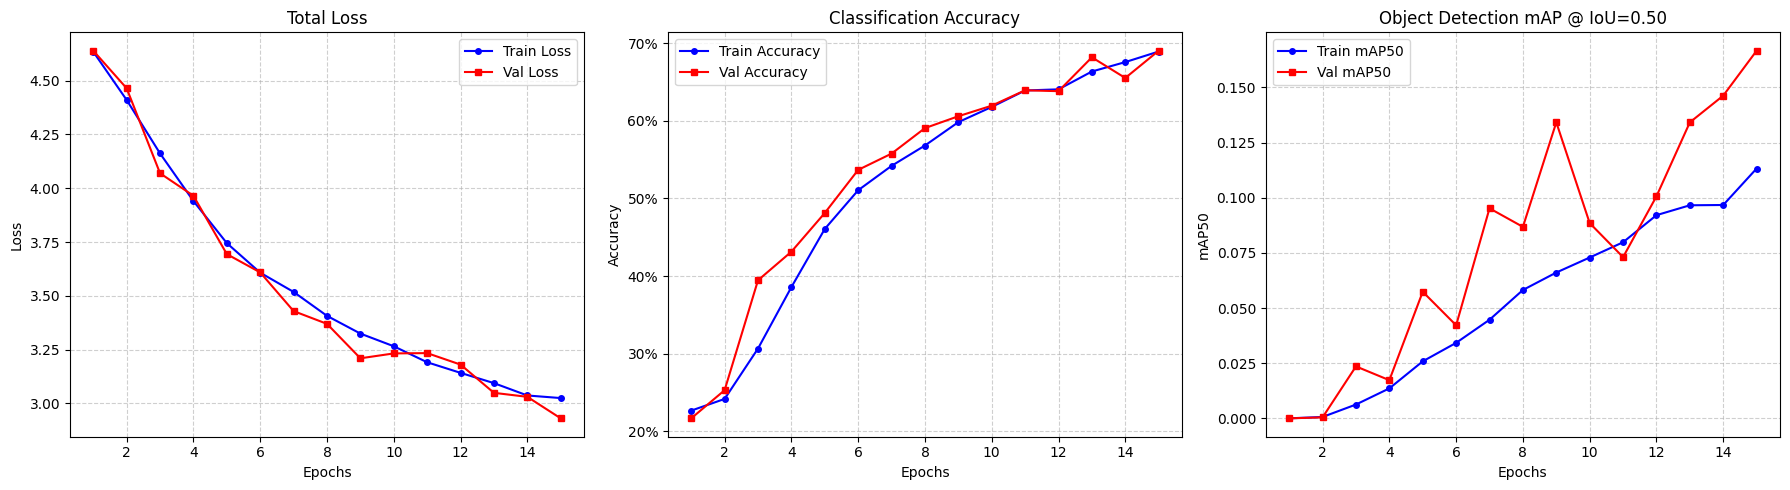

Weights successfully loaded from 'best_baseline.pth' for evaluation.

         AVERAGE TEST MACRO METRICS
Precisión General (Precision): 0.6843
Sensibilidad General (Recall):    0.6625
Detección Final mAP50 (Test):     0.1658

            CLASSIFICATION REPORT              
              precision    recall  f1-score   support

  Background       0.00      0.00      0.00         0
    Object 0       0.94      0.68      0.79       166
    Object 1       0.60      0.68      0.64       193
    Object 2       0.46      0.44      0.45       118
    Object 3       0.63      0.66      0.64       203
    Object 4       0.79      0.85      0.82       203

    accuracy                           0.68       883
   macro avg       0.57      0.55      0.56       883
weighted avg       0.70      0.68      0.68       883

              CONFUSION MATRIX                 
[[113  22  10  16   5]
 [  3 131  12  27  20]
 [  1  24  52  31  10]
 [  3  26  30 134  10]
 [  0  15  10   5 173]]


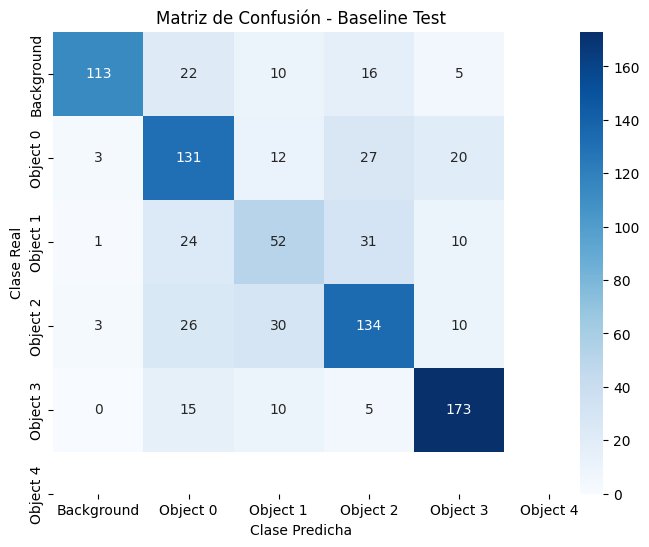

In [18]:
# spatial transformations to prevent spatial position memorization
train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15)
])

val_test_transform = None 

# instantiate datasets
train_dataset = XRayDataset(images_dir=train_images_proc, labels_dir=os.path.join(train_path, "labels"), transform=train_transform)
val_dataset = XRayDataset(images_dir=val_images_proc, labels_dir=os.path.join(val_path, "labels"), transform=val_test_transform)
test_dataset = XRayDataset(images_dir=test_images_proc, labels_dir=os.path.join(test_path, "labels"), transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current execution device: {device}")

model = XRayBaselineModel(num_classes=6)

# run training across 15 epochs to let the network specialize on the small features
metrics_history = train_and_save_baseline(model, train_loader, val_loader, epochs=15, device=device, weights_path="best_baseline.pth")

# plot historical trends
plot_training_curves(metrics_history)

# final evaluation metrics execution
targets, preds = evaluate_on_test(model, test_loader, weights_path="best_baseline.pth", device=device)


In [19]:
def visualize_predictions(model, dataset, num_samples=3, device="cuda"):
    """
    plots a grid of images showing ground truth bounding boxes in green 
    and model predictions in red to inspect performance visually.
    """
    model.eval()
    model.to(device)
    
    # target labels mapping for the titles
    target_names = ['background', 'object 0', 'object 1', 'object 2', 'object 3', 'object 4']
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(8, 5 * num_samples))
    if num_samples == 1:
        axes = [axes]
        
    for i in range(num_samples):
        # pick a random sample from the dataset
        idx = np.random.randint(0, len(dataset))
        image_tensor, target_class, target_bbox = dataset[idx]
        
        # model prediction inference
        with torch.no_grad():
            # add batch dimension and move to device
            input_tensor = image_tensor.unsqueeze(0).to(device)
            cls_pred, bbox_pred = model(input_tensor)
            
            pred_class = torch.argmax(cls_pred, dim=1).item()
            pred_bbox = bbox_pred.squeeze(0).cpu().numpy()
            
        # denormalize image for correct rgb matplotlib display
        img = image_tensor.permute(1, 2, 0).numpy()
        img = img * np.array(XRAY_STD) + np.array(XRAY_MEAN)
        img = np.clip(img, 0, 1)
        
        # get pixel dimensions
        H, W, _ = img.shape
        
        # open canvas to draw rectangles via opencv safely on a copy
        img_canvas = (img.copy() * 255).astype(np.uint8)
        
        # draw ground truth if it is an actual object (class > 0)
        if target_class > 0:
            cx, cy, w, h = target_bbox.numpy()
            xmin = int((cx - w/2) * W)
            ymin = int((cy - h/2) * H)
            xmax = int((cx + w/2) * W)
            ymax = int((cy + h/2) * H)
            cv2.rectangle(img_canvas, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3) # green box
            
        # draw model prediction if it infers an actual object (class > 0)
        if pred_class > 0:
            cx, cy, w, h = pred_bbox
            xmin = int((cx - w/2) * W)
            ymin = int((cy - h/2) * H)
            xmax = int((cx + w/2) * W)
            ymax = int((cy + h/2) * H)
            cv2.rectangle(img_canvas, (xmin, ymin), (xmax, ymax), (255, 0, 0), 3) # red box

        # render results on subplot
        axes[i].imshow(img_canvas)
        axes[i].axis("off")
        
        title_text = (
            f"sample {idx}\n"
            f"gt: {target_names[target_class]} (green)\n"
            f"pred: {target_names[pred_class]} (red)"
        )
        axes[i].set_title(title_text, fontsize=12, loc="left")
        
    plt.tight_layout()
    plt.show()


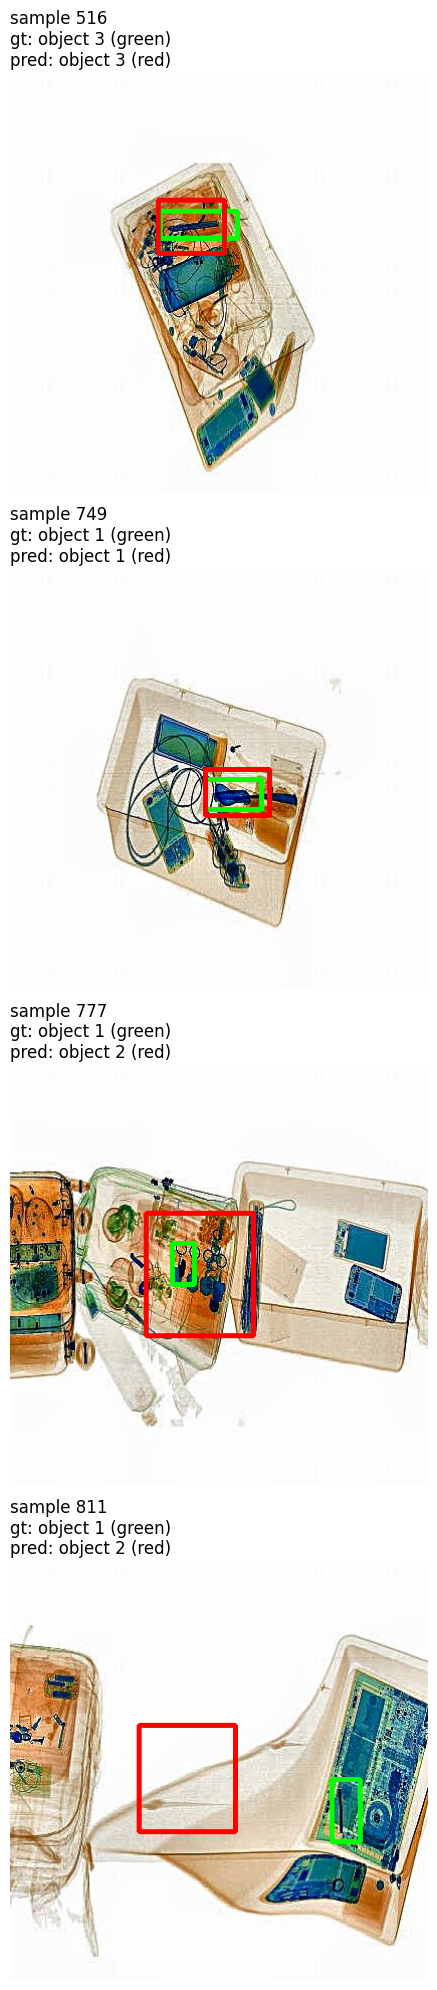

In [20]:
# visual verification of training samples
visualize_predictions(model=model, dataset=test_dataset, num_samples=4, device=device)